In [7]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
INPUT_XLSX   = "process_data_3.xlsx"
EMB_NPY      = "embeddings_resnet50.npy"
PATHS_JSON   = "image_paths.json"
BATCH_SIZE   = 32
IMG_SIZE     = (224, 224)

In [9]:
df = pd.read_excel(INPUT_XLSX)

In [10]:
assert "path" in df.columns, f"{INPUT_XLSX} thiếu cột 'path'!"

all_paths = df["path"].astype(str).tolist()
exists_mask = [os.path.exists(p) for p in all_paths]
paths_valid = [p for p, ok in zip(all_paths, exists_mask) if ok]

print(f"✅ Ảnh tồn tại: {len(paths_valid)}/{len(all_paths)}")
if len(paths_valid) == 0:
    raise ValueError("Không có ảnh hợp lệ để trích xuất đặc trưng!")

# Nếu đã có embedding trước đó thì bỏ qua bước trích xuất
skip_extract = os.path.exists(EMB_NPY) and os.path.exists(PATHS_JSON)
print(f"⏭️  Bỏ qua trích xuất? {skip_extract}")

if not skip_extract:
    import tensorflow as tf
    from tensorflow.keras.applications import ResNet50
    from tensorflow.keras.applications.resnet50 import preprocess_input

    def load_and_preprocess(p):
        img = tf.io.read_file(p)
        img = tf.io.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, IMG_SIZE, method=tf.image.ResizeMethod.BILINEAR)
        img = tf.cast(img, tf.float32)
        img = preprocess_input(img)              # chuẩn ImageNet
        return img

    ds = tf.data.Dataset.from_tensor_slices(paths_valid)
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    print("🔄 Load ResNet50 (ImageNet, pooling=avg)...")
    base = ResNet50(weights="imagenet", include_top=False, pooling="avg")

    embs = []
    for i, batch in enumerate(ds):
        if i % 10 == 0:
            print(f"   batch {i} ...")
        feat = base(batch, training=False).numpy()           # (B, 2048)
        feat = feat / (np.linalg.norm(feat, axis=1, keepdims=True) + 1e-8)  # L2-norm
        embs.append(feat)

    embeddings = np.concatenate(embs, axis=0) if embs else np.zeros((0, 2048), dtype=np.float32)
    np.save(EMB_NPY, embeddings)
    with open(PATHS_JSON, "w", encoding="utf-8") as f:
        json.dump(paths_valid, f, ensure_ascii=False)
    print(f"✅ Saved: {EMB_NPY}  shape={embeddings.shape}")
    print(f"✅ Saved: {PATHS_JSON}  n_paths={len(paths_valid)}")
else:
    embeddings = np.load(EMB_NPY)
    with open(PATHS_JSON, "r") as f:
        paths_valid = json.load(f)
    print(f"📦 Dùng lại embeddings: {EMB_NPY} shape={embeddings.shape}")
    print(f"📦 Dùng lại paths: {len(paths_valid)}")

✅ Ảnh tồn tại: 500/500
⏭️  Bỏ qua trích xuất? True
📦 Dùng lại embeddings: embeddings_resnet50.npy shape=(500, 2048)
📦 Dùng lại paths: 500


In [11]:
from sklearn.decomposition import PCA

✅ PCA: 2048 → 216 chiều | Explained variance = 95.03%
💾 Saved: embeddings_pca.npy  &  features_reduced.csv


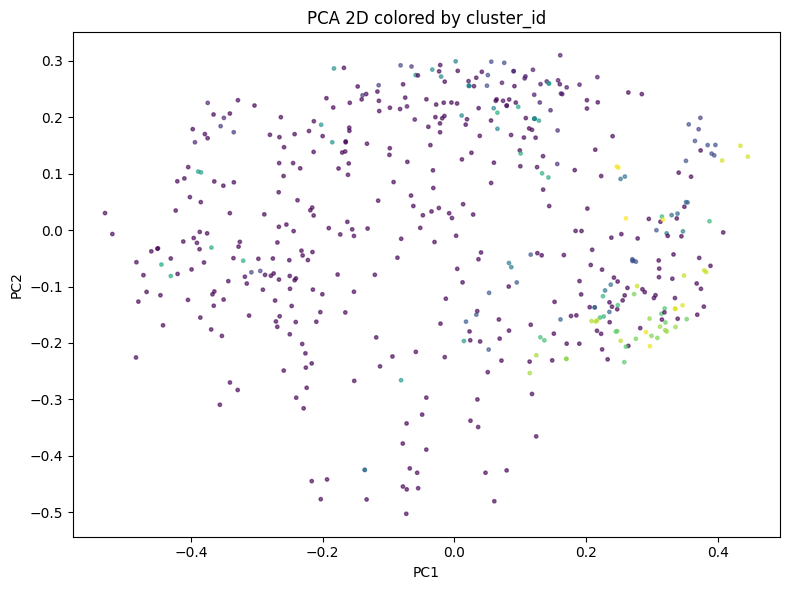

In [12]:
assert embeddings.shape[0] == len(paths_valid), "Số embedding không khớp số path!"

# PCA giữ >=95% variance
pca = PCA(n_components=0.95, svd_solver="full", random_state=42)
emb_pca = pca.fit_transform(embeddings)

print(f"✅ PCA: {embeddings.shape[1]} → {emb_pca.shape[1]} chiều | "
    f"Explained variance = {pca.explained_variance_ratio_.sum()*100:.2f}%")

# Lưu kết quả
np.save("embeddings_pca.npy", emb_pca)

# Ghép path vào CSV
out_df = pd.DataFrame(emb_pca)
out_df.insert(0, "path", paths_valid)
out_df.to_csv("features_reduced.csv", index=False)
print("💾 Saved: embeddings_pca.npy  &  features_reduced.csv")

# 2D scatter bằng 2 PC đầu (nếu >=2)
if emb_pca.shape[1] >= 2:
    # nối nhãn để tô màu nếu có
    meta = df.set_index("path", drop=False)
    meta_idx = [meta.loc[p] if p in meta.index else None for p in paths_valid]

    # default color: 1 màu
    colors = "C0"
    labels = None

    # Nếu có cluster_id hoặc category thì lấy ra để tô màu
    if all((m is not None and "cluster_id" in m) for m in meta_idx):
        labels = [int(m["cluster_id"]) if m is not None else -1 for m in meta_idx]
        colors = labels
        title = "PCA 2D colored by cluster_id"
    elif all((m is not None and "category" in m) for m in meta_idx):
        labels = [str(m["category"]) if m is not None else "unknown" for m in meta_idx]
        # vẽ đơn giản: không legend cho quá nhiều lớp
        title = "PCA 2D colored by category"
    else:
        title = "PCA 2D (first two components)"

    plt.figure(figsize=(8,6))
    if labels is None:
        plt.scatter(emb_pca[:,0], emb_pca[:,1], s=6, alpha=0.5)
    else:
        # với nhiều lớp, dùng scatter đơn giản (legend có thể quá dài)
        plt.scatter(emb_pca[:,0], emb_pca[:,1], s=6, alpha=0.6, c=colors)
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()

In [13]:
from sklearn.manifold import TSNE

⏳ t-SNE on 500 points ... (có thể mất vài phút)


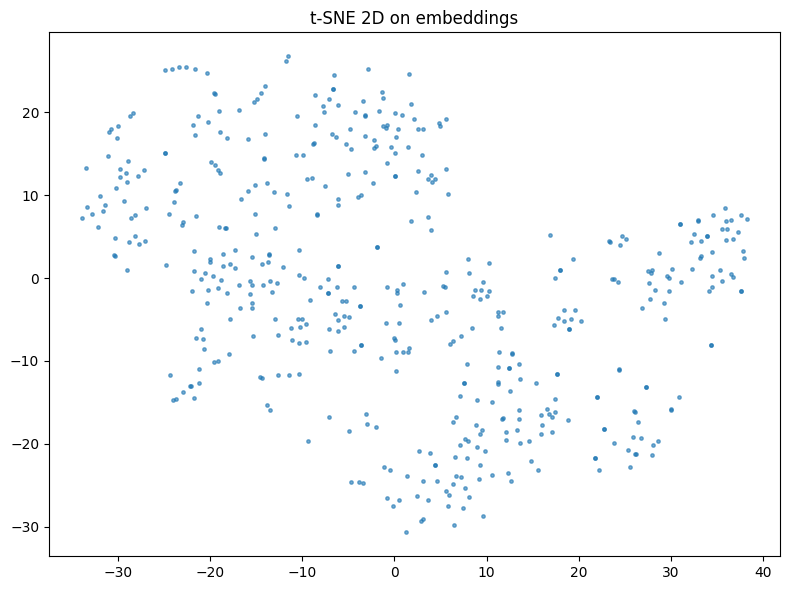

In [14]:
MAX_TSNE = 2000  # nếu ảnh quá nhiều, sample để t-SNE không quá chậm
X = embeddings  # có thể dùng emb_pca nếu muốn t-SNE nhanh hơn

if len(X) > MAX_TSNE:
    idx = np.random.RandomState(42).choice(len(X), MAX_TSNE, replace=False)
    X_tsne_in = X[idx]
    paths_tsne = [paths_valid[i] for i in idx]
else:
    X_tsne_in = X
    paths_tsne = paths_valid

print(f"⏳ t-SNE on {len(X_tsne_in)} points ... (có thể mất vài phút)")
tsne2 = TSNE(n_components=2, learning_rate="auto", init="pca", perplexity=30, random_state=42)
Y = tsne2.fit_transform(X_tsne_in)

plt.figure(figsize=(8,6))
plt.scatter(Y[:,0], Y[:,1], s=6, alpha=0.6)
plt.title("t-SNE 2D on embeddings")
plt.tight_layout()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


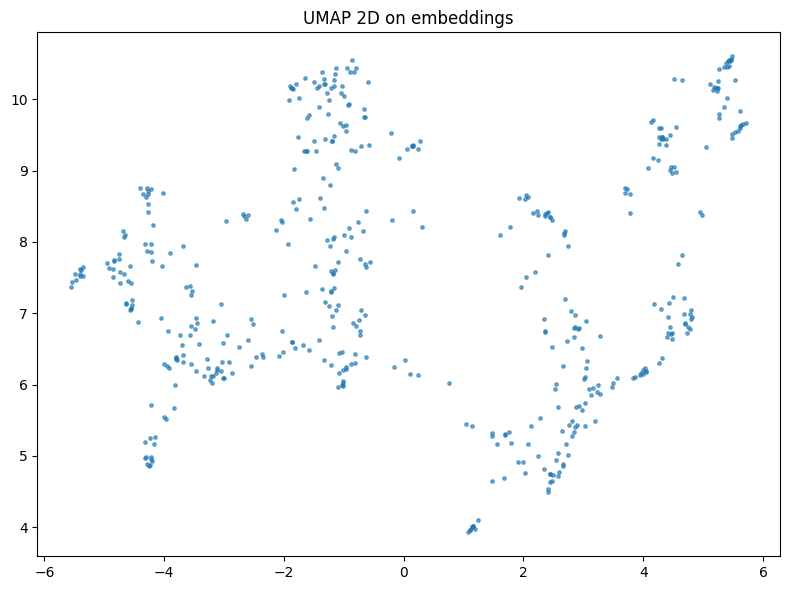

In [16]:
import umap

reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
Y_umap = reducer.fit_transform(embeddings)

plt.figure(figsize=(8,6))
plt.scatter(Y_umap[:,0], Y_umap[:,1], s=6, alpha=0.6)
plt.title("UMAP 2D on embeddings")
plt.tight_layout()
plt.show()